<a href="https://colab.research.google.com/github/justiniandata/HW-Week-8/blob/main/DS_Bootcamp_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DS Bootcamp
Spring 2025

In [ ]:
import pandas as pd
import numpy as np
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
import torch

In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("kashishparmar02/social-media-sentiments-analysis-dataset")

# Find the CSV file within the downloaded directory
for filename in os.listdir(path):
    if filename.endswith(".csv"):
        csv_file_path = os.path.join(path, filename)
        break  # Stop after finding the first CSV file

print("Path to dataset files:", csv_file_path)

# Load the dataset
data = pd.read_csv(csv_file_path)  # Use the path to the CSV file

# Display the first few rows of the dataset
print(data.head())

# Load RoBERTa sentiment model
model_name = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
labels = ['negative', 'neutral', 'positive']

# Sentiment analysis function
def get_sentiment(text):
    try:
        text = str(text).replace("@", "@user").replace("http", "http")
        encoded_input = tokenizer(text, return_tensors='pt', truncation=True)
        with torch.no_grad():
            output = model(**encoded_input)
        scores = output.logits[0].numpy()
        probs = softmax(scores)
        sentiment = labels[probs.argmax()]
        confidence = probs.max()
        return pd.Series([sentiment, confidence])
    except:
        return pd.Series(["error", 0])

# Apply to data
data[['predicted_sentiment', 'confidence']] = data['Text'].apply(get_sentiment)
print(data[['Text', 'predicted_sentiment', 'confidence']].head())

Path to dataset files: /root/.cache/kagglehub/datasets/kashishparmar02/social-media-sentiments-analysis-dataset/versions/3/sentimentdataset.csv
   Unnamed: 0.1  Unnamed: 0  \
0             0           0   
1             1           1   
2             2           2   
3             3           3   
4             4           4   

                                                Text    Sentiment  \
0   Enjoying a beautiful day at the park!        ...   Positive     
1   Traffic was terrible this morning.           ...   Negative     
2   Just finished an amazing workout! 💪          ...   Positive     
3   Excited about the upcoming weekend getaway!  ...   Positive     
4   Trying out a new recipe for dinner tonight.  ...   Neutral      

             Timestamp            User     Platform  \
0  2023-01-15 12:30:00   User123          Twitter     
1  2023-01-15 08:45:00   CommuterX        Twitter     
2  2023-01-15 15:45:00   FitnessFan      Instagram    
3  2023-01-15 18:20:00   Adventure

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


                                                Text predicted_sentiment  \
0   Enjoying a beautiful day at the park!        ...            positive   
1   Traffic was terrible this morning.           ...            negative   
2   Just finished an amazing workout! 💪          ...            positive   
3   Excited about the upcoming weekend getaway!  ...            positive   
4   Trying out a new recipe for dinner tonight.  ...             neutral   

   confidence  
0    0.991143  
1    0.959336  
2    0.988204  
3    0.992366  
4    0.789786  


In [ ]:
# Load j-hartmann emotion model
emotion_model_name = "j-hartmann/emotion-english-distilroberta-base"
emotion_tokenizer = AutoTokenizer.from_pretrained(emotion_model_name)
emotion_model = AutoModelForSequenceClassification.from_pretrained(emotion_model_name)

# Emotion labels (from model card)
emotion_labels = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']

def get_emotion(text):
    try:
        text = str(text)
        inputs = emotion_tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
        with torch.no_grad():
            outputs = emotion_model(**inputs)
        scores = outputs.logits[0].numpy()
        probs = softmax(scores)
        emotion = emotion_labels[probs.argmax()]
        confidence = probs.max()
        return pd.Series([emotion, confidence])
    except:
        return pd.Series(["error", 0])

data[['predicted_sentiment', 'confidence']] = data['Text'].apply(get_sentiment)

data[['predicted_emotion', 'emotion_confidence']] = data['Text'].apply(get_emotion)

print(data[['Text', 'predicted_sentiment', 'confidence', 'predicted_emotion', 'emotion_confidence']].head())

                                                Text predicted_sentiment  \
0   Enjoying a beautiful day at the park!        ...            positive   
1   Traffic was terrible this morning.           ...            negative   
2   Just finished an amazing workout! 💪          ...            positive   
3   Excited about the upcoming weekend getaway!  ...            positive   
4   Trying out a new recipe for dinner tonight.  ...             neutral   

   confidence predicted_emotion  emotion_confidence  
0    0.991143               joy            0.982210  
1    0.959336              fear            0.973239  
2    0.988204               joy            0.898432  
3    0.992366               joy            0.947705  
4    0.789786               joy            0.537313  


In [ ]:
# Check the shape of the dataset
print(f'Dataset shape: {data.shape}')

# Check for missing values
print(data.isnull().sum())

# Display basic statistics
print(data.describe())

In [ ]:
# Download the VADER lexicon for sentiment analysis
nltk.download('vader_lexicon')

In [ ]:
# Display the column names
print(data.columns)

In [ ]:
# Initialize the sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Function to calculate sentiment
def get_sentiment(text):
    if isinstance(text, str):  # Check if the input is a string
        score = sia.polarity_scores(text)
        return score['compound']  # Return the compound score
    else:
        return np.nan  # Return NaN for non-string inputs

# Apply the sentiment function to the 'Text' column
data['Sentiment'] = data['Text'].apply(get_sentiment)  # Use 'Text' as the column name

# Display the updated dataframe with sentiment scores
print(data[['Text', 'Sentiment']].head())  # Display the 'Text' and 'Sentiment' columns

                                                Text  Sentiment
0   Enjoying a beautiful day at the park!        ...     0.8221
1   Traffic was terrible this morning.           ...    -0.4767
2   Just finished an amazing workout! 💪          ...     0.6239
3   Excited about the upcoming weekend getaway!  ...     0.4003
4   Trying out a new recipe for dinner tonight.  ...     0.0000


### Sentiment Classification

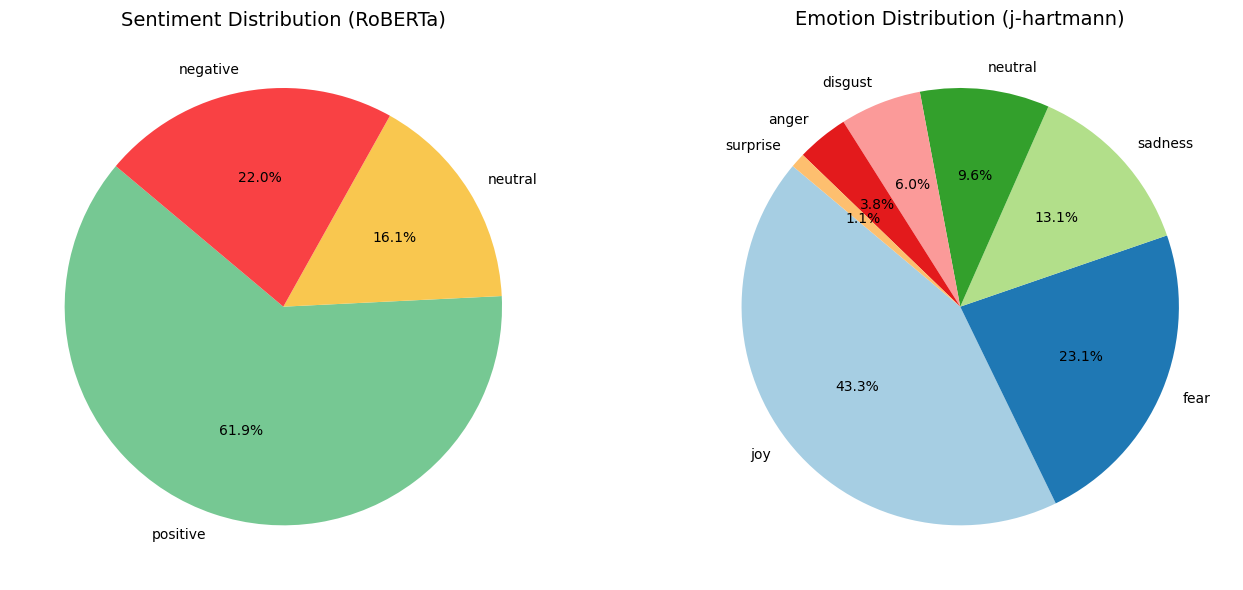

In [ ]:
import matplotlib.pyplot as plt

# Compute normalized sentiment and emotion distributions
sentiment_counts = data['predicted_sentiment'].value_counts(normalize=True).reindex(['positive', 'neutral', 'negative']) * 100
emotion_counts = data['predicted_emotion'].value_counts(normalize=True).sort_values(ascending=False) * 100

# Define custom colors
sentiment_colors = ['#76c893', '#f9c74f', '#f94144']  # green, yellow, red
emotion_colors = plt.cm.Paired.colors[:len(emotion_counts)]

# Set up figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart: Sentiment
axes[0].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=sentiment_colors, startangle=140)
axes[0].set_title('Sentiment Distribution (RoBERTa)', fontsize=14)

# Pie chart: Emotion
axes[1].pie(emotion_counts, labels=emotion_counts.index, autopct='%1.1f%%', colors=emotion_colors, startangle=140)
axes[1].set_title('Emotion Distribution (j-hartmann)', fontsize=14)

# Format layout
plt.tight_layout()
plt.show()

In [ ]:
# Mapping emotion labels to sentiment categories
emotion_to_sentiment = {
    'joy': 'positive',
    'surprise': 'positive',
    'neutral': 'neutral',
    'anger': 'negative',
    'sadness': 'negative',
    'fear': 'negative',
    'disgust': 'negative'
}

# Add mapped sentiment column based on emotion
data['mapped_sentiment'] = data['predicted_emotion'].map(emotion_to_sentiment)

In [ ]:
# Outer ring: emotion counts (grouped by sentiment)
emotion_counts_grouped = data.groupby(['mapped_sentiment', 'predicted_emotion']).size()

# Inner ring: sentiment counts (from mapped sentiment)
sentiment_counts_grouped = data['mapped_sentiment'].value_counts()


In [ ]:
# Mapping emotion to sentiment category
emotion_to_sentiment = {
    'joy': 'positive',
    'surprise': 'positive',
    'neutral': 'neutral',
    'anger': 'negative',
    'sadness': 'negative',
    'fear': 'negative',
    'disgust': 'negative'
}

# Apply map
data['mapped_sentiment'] = data['predicted_emotion'].map(emotion_to_sentiment)

# Count how many posts fall under each sentiment-emotion combo
sentiment_emotion_counts = data.groupby(['mapped_sentiment', 'predicted_emotion']).size().reset_index(name='count')

import plotly.express as px

fig = px.sunburst(
    sentiment_emotion_counts,
    path=['mapped_sentiment', 'predicted_emotion'],
    values='count',
    color='mapped_sentiment',
    color_discrete_map={
        'positive': 'green',
        'neutral': 'gray',
        'negative': 'red'
    },
    title='Sentiment-to-Emotion Breakdown (Nested Sunburst)'
)

fig.update_traces(textinfo='label+percent entry')
fig.show()


In [ ]:
# Drop nulls to ensure clean data
sunburst_df = data[['predicted_sentiment', 'predicted_emotion']].dropna()

# Count how many posts fall under each (sentiment → emotion) pair
sentiment_to_emotion = (
    sunburst_df.groupby(['predicted_sentiment', 'predicted_emotion'])
    .size()
    .reset_index(name='count')
)

import plotly.express as px

fig = px.sunburst(
    sentiment_to_emotion,
    path=['predicted_sentiment', 'predicted_emotion'],
    values='count',
    color='predicted_sentiment',
    color_discrete_map={
        'positive': '#76c893',
        'neutral': '#f9c74f',
        'negative': '#f94144'
    },
    title='Sentiment to Emotion Nested Pie'
)

fig.update_traces(textinfo='label+percent entry')
fig.show()

<ipython-input-23-58be5c14067e>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='predicted_sentiment', palette='pastel', order=['positive', 'neutral', 'negative'])


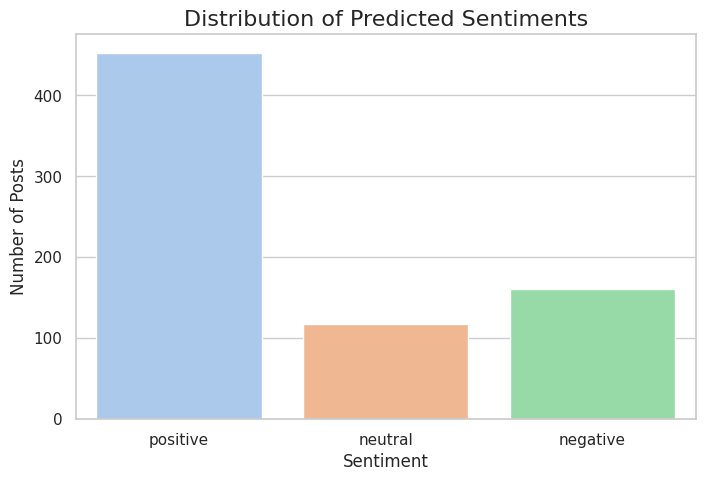

In [ ]:
"""
# Classify sentiment into categories
sentiment_categories = pd.cut(data['Sentiment'], bins=[-1, -0.05, 0.05, 1], labels=['Negative', 'Neutral', 'Positive'])
sentiment_counts = sentiment_categories.value_counts()

# Plotting
plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90, colors=['red', 'grey', 'green'])
plt.title('Sentiment Classification')
plt.axis('equal')  # Equal aspect ratio ensures pie chart is circular
plt.show()
"""

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Count of each sentiment
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='predicted_sentiment', palette='pastel', order=['positive', 'neutral', 'negative'])

plt.title("Distribution of Predicted Sentiments", fontsize=16)
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts")
plt.show()

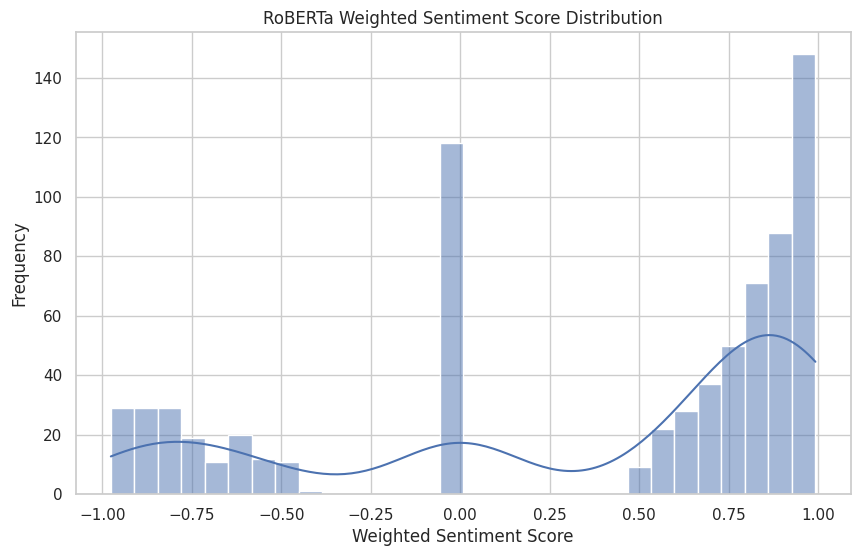

In [ ]:
"""
Map sentiments to numbers:
- negative = -1
- neutral = 0
- positive = +1

Multiply by confidence (optional for weighting)
"""

# Map sentiments to numeric values
sentiment_map = {'negative': -1, 'neutral': 0, 'positive': 1}
data['roberta_score'] = data['predicted_sentiment'].map(sentiment_map)

# Optionally weight by confidence
data['weighted_score'] = data['roberta_score'] * data['confidence']

# Plot histogram of weighted scores
plt.figure(figsize=(10, 6))
sns.histplot(data['weighted_score'], bins=30, kde=True)
plt.title('RoBERTa Weighted Sentiment Score Distribution')
plt.xlabel('Weighted Sentiment Score')
plt.ylabel('Frequency')
plt.show()

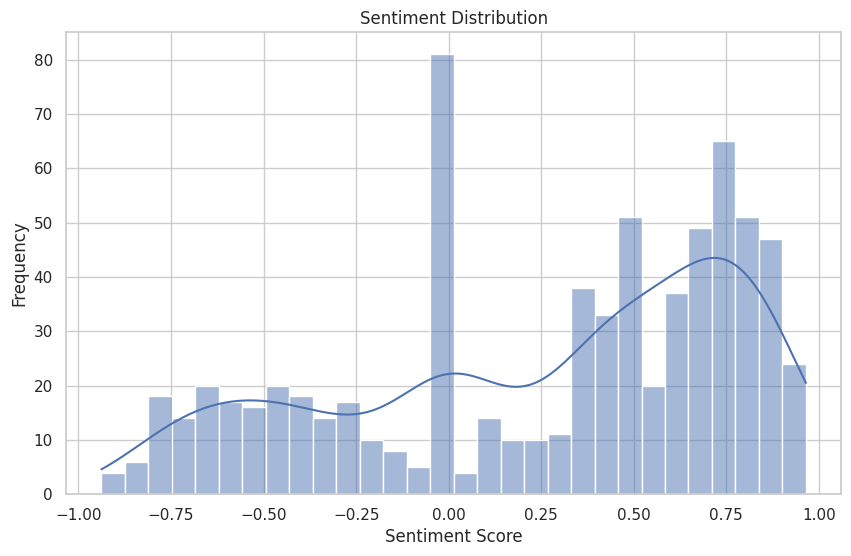

In [ ]:
# Set the style of seaborn
sns.set(style='whitegrid')

# Plot the sentiment distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['Sentiment'], bins=30, kde=True)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()

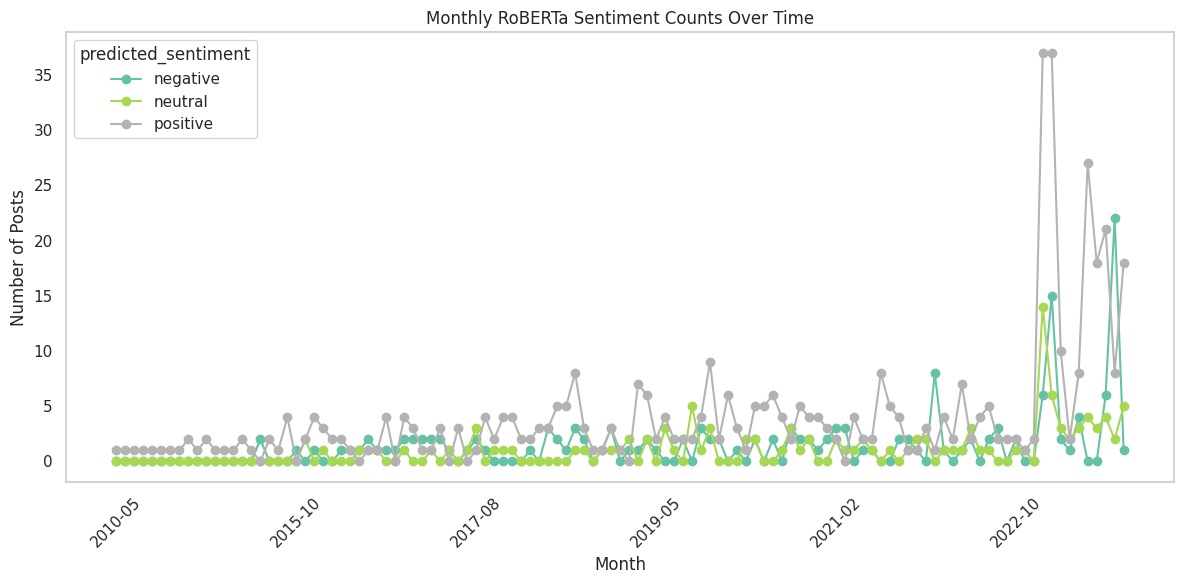

In [ ]:
# Ensure 'Timestamp' is datetime
data['Timestamp'] = pd.to_datetime(data['Timestamp'])

# Add a 'month' column for grouping
data['Month'] = data['Timestamp'].dt.to_period('M').astype(str)

# Count of sentiments per month
monthly_counts = data.groupby(['Month', 'predicted_sentiment']).size().unstack(fill_value=0)

# Plot
monthly_counts.plot(kind='line', marker='o', figsize=(12, 6), colormap='Set2')
plt.title('Monthly RoBERTa Sentiment Counts Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

### Engagement vs. Sentiment

<ipython-input-7-4926df97dd13>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='predicted_sentiment', y='Likes', palette='muted', order=['positive', 'neutral', 'negative'])


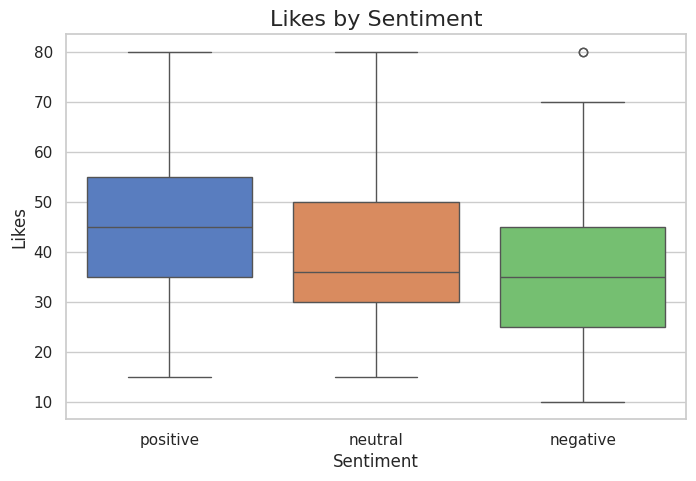

<ipython-input-7-4926df97dd13>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='predicted_sentiment', y='Retweets', palette='muted', order=['positive', 'neutral', 'negative'])


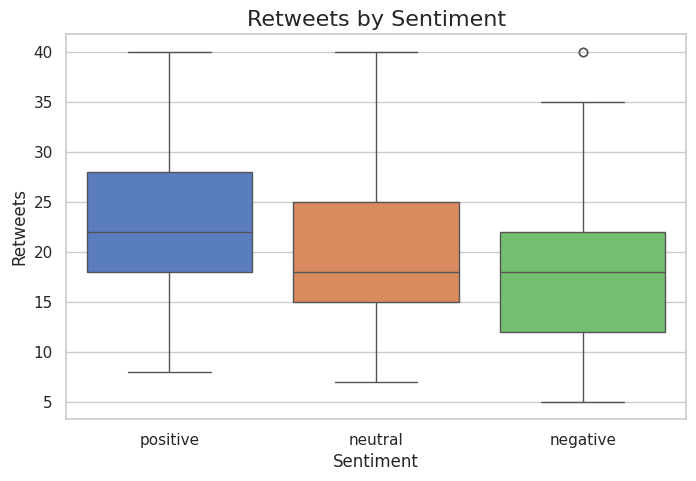

In [ ]:
#Average Likes and Retweets and Compare to the setiments

# Likes
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='predicted_sentiment', y='Likes', palette='muted', order=['positive', 'neutral', 'negative'])
plt.title("Likes by Sentiment", fontsize=16)
plt.xlabel("Sentiment")
plt.ylabel("Likes")
plt.show()

# Retweets
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='predicted_sentiment', y='Retweets', palette='muted', order=['positive', 'neutral', 'negative'])
plt.title("Retweets by Sentiment", fontsize=16)
plt.xlabel("Sentiment")
plt.ylabel("Retweets")
plt.show()

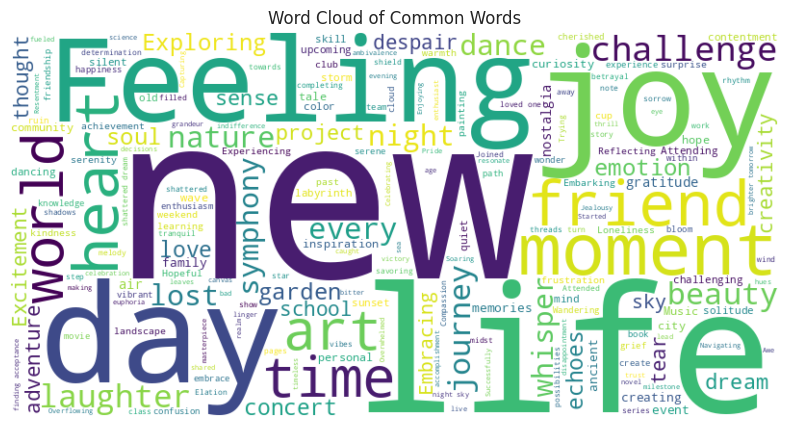

In [ ]:
from wordcloud import WordCloud

# Combine all text into a single string
text_combined = ' '.join(data['Text'].dropna())

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_combined)

# Plotting
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Common Words')
plt.show()

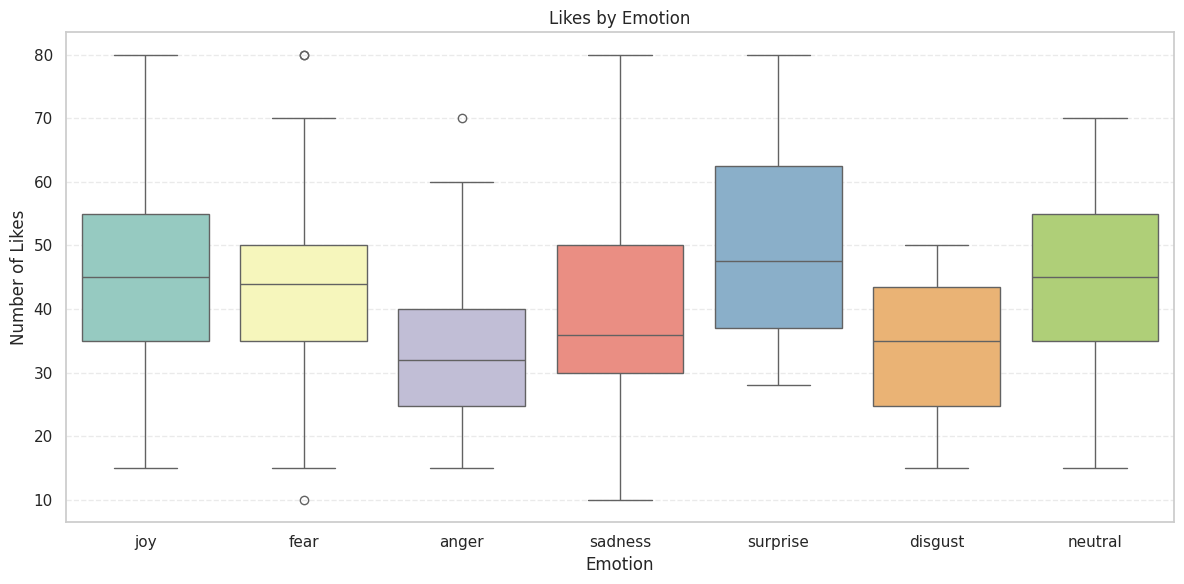

In [ ]:
# Remove missing values if any
emotion_engagement = data[['predicted_emotion', 'Likes', 'Retweets']].dropna()

# Optional: clean emotion labels (just in case)
emotion_engagement['predicted_emotion'] = emotion_engagement['predicted_emotion'].str.strip().str.lower()

#Box Plot — Likes by Emotion
plt.figure(figsize=(12, 6))
sns.boxplot(data=emotion_engagement, x='predicted_emotion', y='Likes', palette='Set3')
plt.title('Likes by Emotion')
plt.xlabel('Emotion')
plt.ylabel('Number of Likes')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



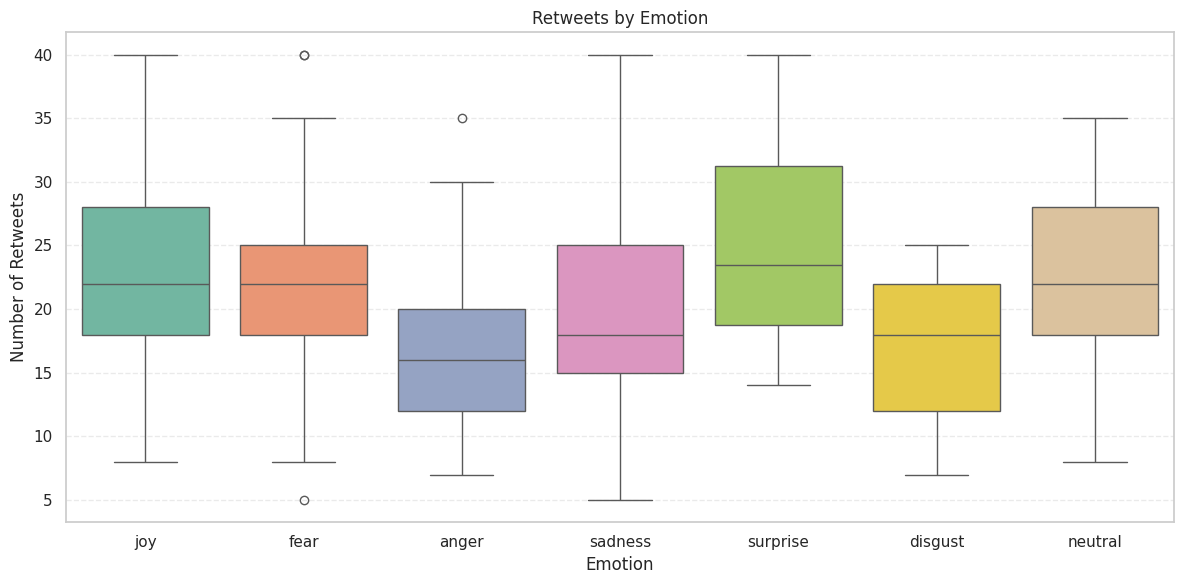

In [ ]:
#Box Plot — Retweets by Emotion
plt.figure(figsize=(12, 6))
sns.boxplot(data=emotion_engagement, x='predicted_emotion', y='Retweets', palette='Set2')
plt.title('Retweets by Emotion')
plt.xlabel('Emotion')
plt.ylabel('Number of Retweets')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

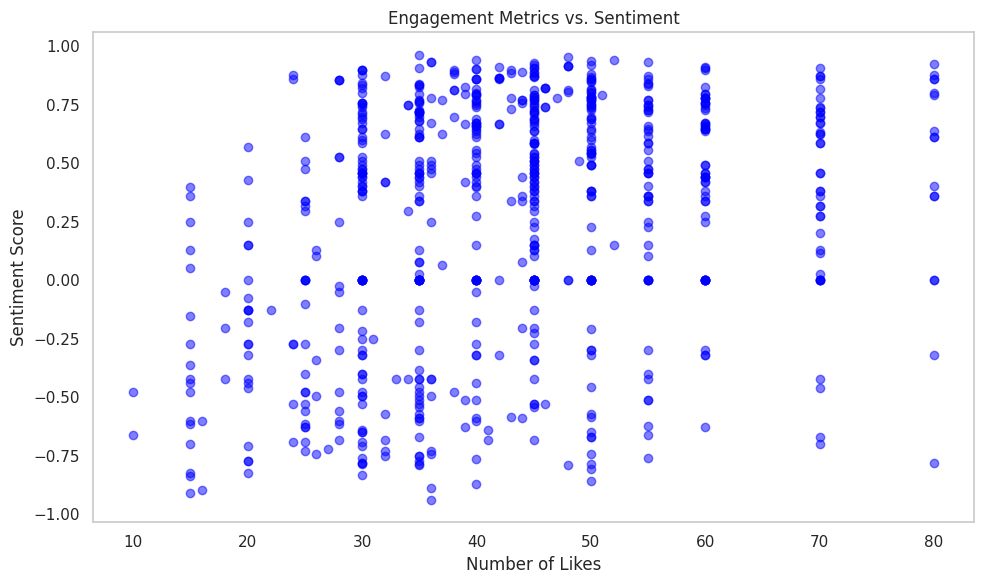

In [ ]:
# Scatter plot of Likes vs. Sentiment
plt.figure(figsize=(10, 6))
plt.scatter(data['Likes'], data['Sentiment'], alpha=0.5, color='blue')
plt.title('Engagement Metrics vs. Sentiment')
plt.xlabel('Number of Likes')
plt.ylabel('Sentiment Score')
plt.grid()
plt.tight_layout()
plt.show()

### Hashtag and Topic Trends

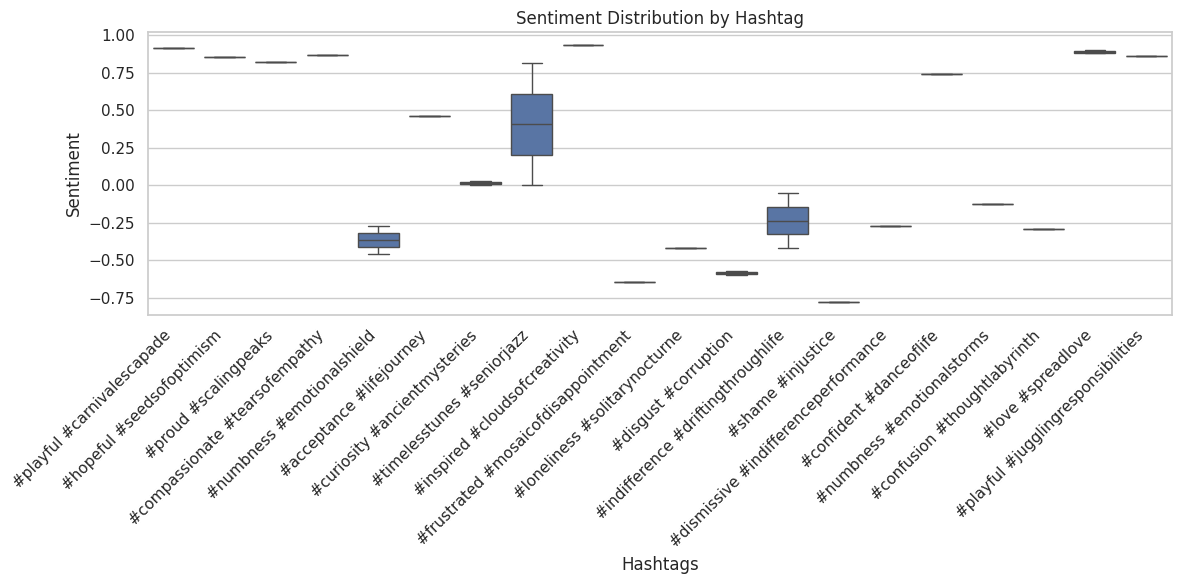

In [ ]:
# Ensure 'Hashtags' column is treated as a list, then explode it
data['Hashtags'] = data['Hashtags'].apply(lambda x: x.split(',') if isinstance(x, str) else [])
hashtags_exploded = data.explode('Hashtags')

# Strip spaces and convert hashtags to lowercase for consistency
hashtags_exploded['Hashtags'] = hashtags_exploded['Hashtags'].str.strip().str.lower()

# Get the top 20 most used hashtags
top_hashtags = hashtags_exploded['Hashtags'].value_counts().nlargest(20).index

# Filter data for only the top hashtags
filtered_data = hashtags_exploded[hashtags_exploded['Hashtags'].isin(top_hashtags)]

# Plotting
plt.figure(figsize=(12, 6))
sns.boxplot(x='Hashtags', y='Sentiment', data=filtered_data, order=top_hashtags)  # Order by frequency
plt.title('Sentiment Distribution by Hashtag')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()


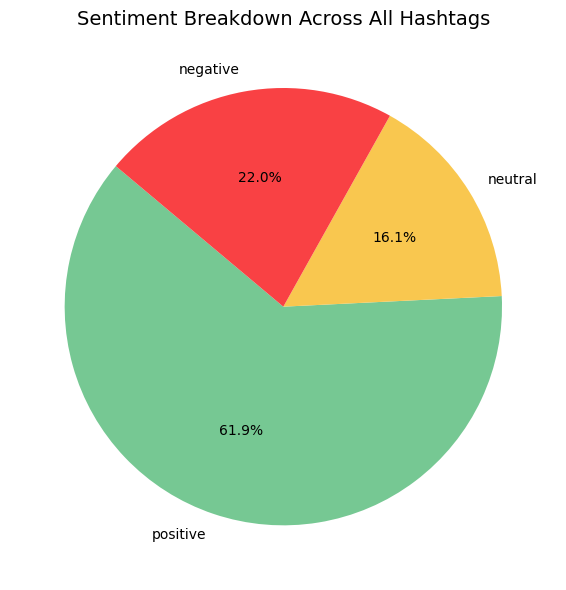

In [ ]:
# Drop missing hashtag or sentiment entries
df = data[['Hashtags', 'predicted_sentiment']].dropna()

# Expand hashtags into rows
expanded = []
for _, row in df.iterrows():
    tags = str(row['Hashtags']).replace('#', ' ').split()
    for tag in tags:
        clean_tag = tag.strip().lower()
        if clean_tag:
            expanded.append((clean_tag, row['predicted_sentiment']))

# Create expanded DataFrame
hashtags_df = pd.DataFrame(expanded, columns=['Hashtag', 'Sentiment'])

# Count sentiment occurrences (as percentages)
sentiment_counts = hashtags_df['Sentiment'].value_counts(normalize=True) * 100
sentiment_counts = sentiment_counts.reindex(['positive', 'neutral', 'negative'])

# Define better colors
colors = ['#76c893', '#f9c74f', '#f94144']

# Plot
plt.figure(figsize=(6, 6))
plt.pie(sentiment_counts, labels=sentiment_counts.index,
        autopct='%1.1f%%', startangle=140, colors=colors)

plt.title('Sentiment Breakdown Across All Hashtags', fontsize=14)
plt.tight_layout()
plt.show()



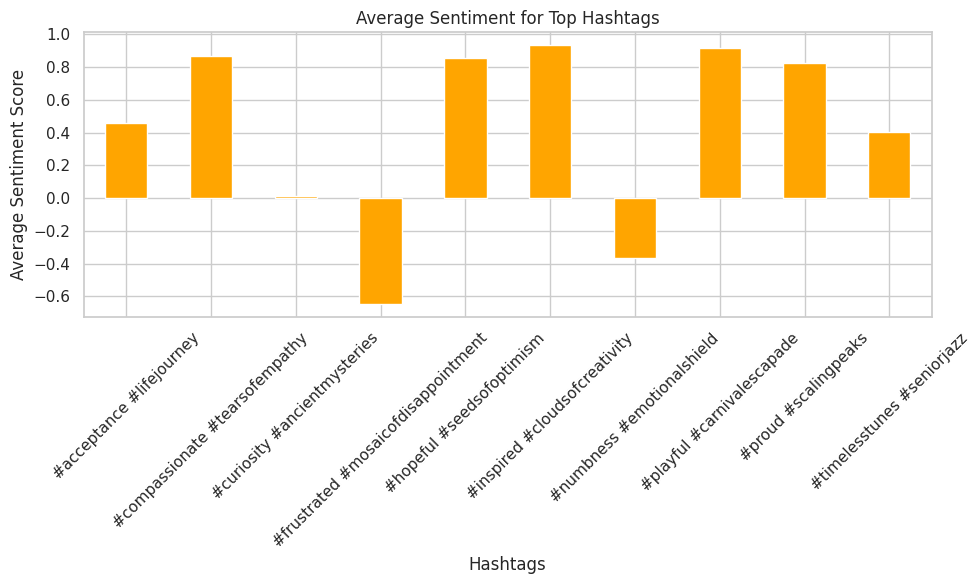

In [ ]:
# Group by hashtags and calculate average sentiment
top_hashtags = hashtags_exploded['Hashtags'].value_counts().nlargest(10).index
top_hashtags_sentiment = hashtags_exploded[hashtags_exploded['Hashtags'].isin(top_hashtags)].groupby('Hashtags')['Sentiment'].mean()

# Plotting
plt.figure(figsize=(10, 6))
top_hashtags_sentiment.plot(kind='bar', color='orange')
plt.title('Average Sentiment for Top Hashtags')
plt.xlabel('Hashtags')
plt.ylabel('Average Sentiment Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

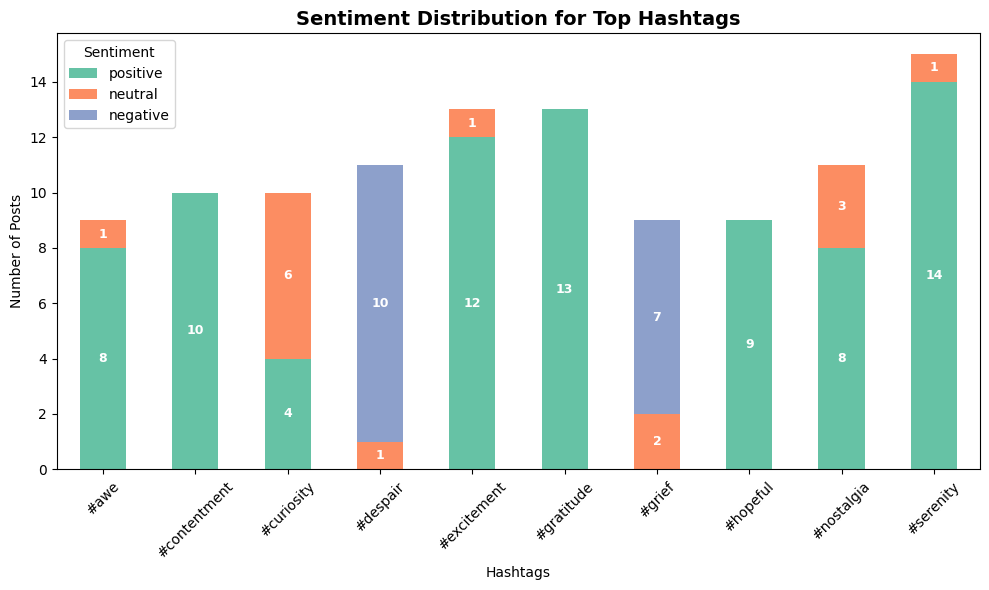

In [ ]:
# Custom colors (optional)
custom_colors = ['#66c2a5', '#fc8d62', '#8da0cb']
sentiment_counts = sentiment_counts[['positive', 'neutral', 'negative']]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
sentiment_counts.plot(kind='bar', stacked=True, color=custom_colors, ax=ax)

# Title and labels
ax.set_title('Sentiment Distribution for Top Hashtags', fontsize=14, weight='bold')
ax.set_xlabel('Hashtags')
ax.set_ylabel('Number of Posts')
plt.xticks(rotation=45)

# Add '#' to x-axis labels
ax.set_xticklabels([f"#{label.get_text()}" for label in ax.get_xticklabels()])

# Add value labels inside the bars
for i, hashtag in enumerate(sentiment_counts.index):
    y_offset = 0
    for sentiment, color in zip(sentiment_counts.columns, custom_colors):
        value = sentiment_counts.loc[hashtag, sentiment]
        if value > 0:
            ax.text(i, y_offset + value / 2, f'{int(value)}',
                    ha='center', va='center', fontsize=9, color='white', weight='bold')
            y_offset += value

plt.tight_layout()
plt.show()

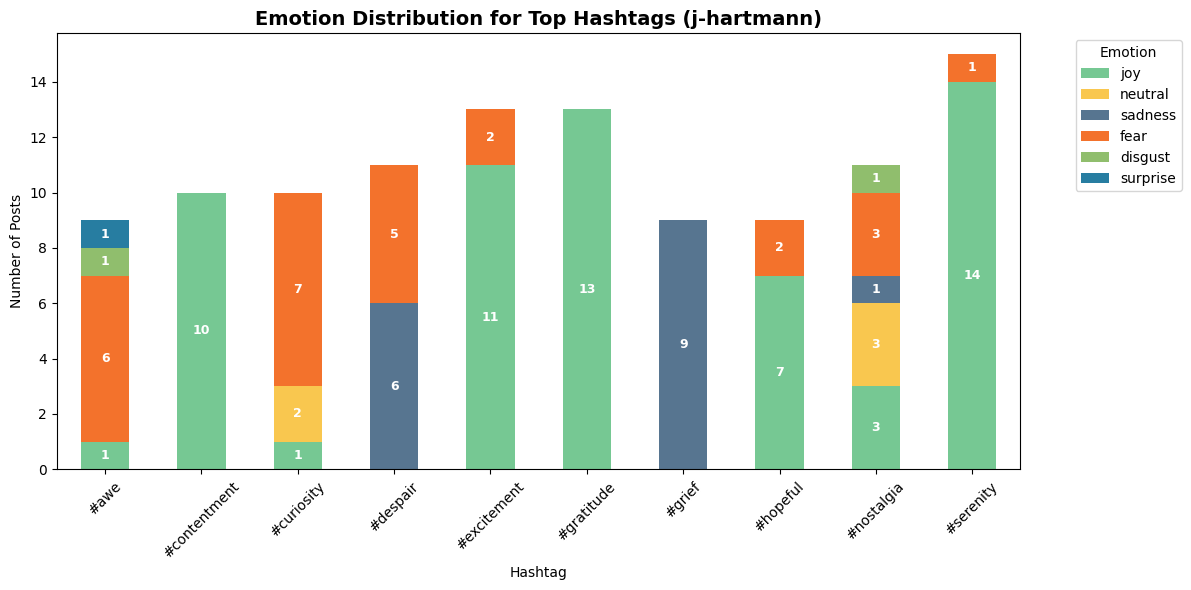

In [ ]:
# Filter out missing hashtag/emotion rows
df_emotion = data[['Hashtags', 'predicted_emotion']].dropna()

# Expand hashtags
expanded_emotion = []
for _, row in df_emotion.iterrows():
    tags = str(row['Hashtags']).replace('#', ' ').split()
    for tag in tags:
        clean_tag = tag.strip().lower()
        if clean_tag:
            expanded_emotion.append((clean_tag, row['predicted_emotion']))

# Create DataFrame
hashtags_emotion_df = pd.DataFrame(expanded_emotion, columns=['Hashtag', 'Emotion'])

# Top 10 hashtags by frequency
top_emotion_tags = hashtags_emotion_df['Hashtag'].value_counts().nlargest(10).index
top_emotion_df = hashtags_emotion_df[hashtags_emotion_df['Hashtag'].isin(top_emotion_tags)]

# Group and pivot
emotion_counts = top_emotion_df.groupby(['Hashtag', 'Emotion']).size().unstack(fill_value=0)
emotion_counts = emotion_counts.sort_index()  # Optional: alphabetical order

# Choose custom color palette (adjustable)
emotion_palette = {
    'joy': '#76c893',
    'neutral': '#f9c74f',
    'anger': '#f94144',
    'sadness': '#577590',
    'fear': '#f3722c',
    'disgust': '#90be6d',
    'surprise': '#277da1'
}

# Ensure consistent order
emotion_counts = emotion_counts[[e for e in emotion_palette if e in emotion_counts.columns]]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
emotion_counts.plot(kind='bar', stacked=True, color=[emotion_palette[e] for e in emotion_counts.columns], ax=ax)

# Add labels like #23
for i, hashtag in enumerate(emotion_counts.index):
    y_offset = 0
    for emotion, color in zip(emotion_counts.columns, [emotion_palette[e] for e in emotion_counts.columns]):
        value = emotion_counts.loc[hashtag, emotion]
        if value > 0:
            ax.text(i, y_offset + value / 2, f'{int(value)}',
                    ha='center', va='center', fontsize=9, color='white', weight='bold')
            y_offset += value

# Formatting
ax.set_title('Emotion Distribution for Top Hashtags (j-hartmann)', fontsize=14, weight='bold')
ax.set_xlabel('Hashtag')
ax.set_ylabel('Number of Posts')
plt.xticks(rotation=45)

# Add '#' in front of each hashtag on x-axis
ax.set_xticklabels([f"#{label.get_text()}" for label in ax.get_xticklabels()])

plt.legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

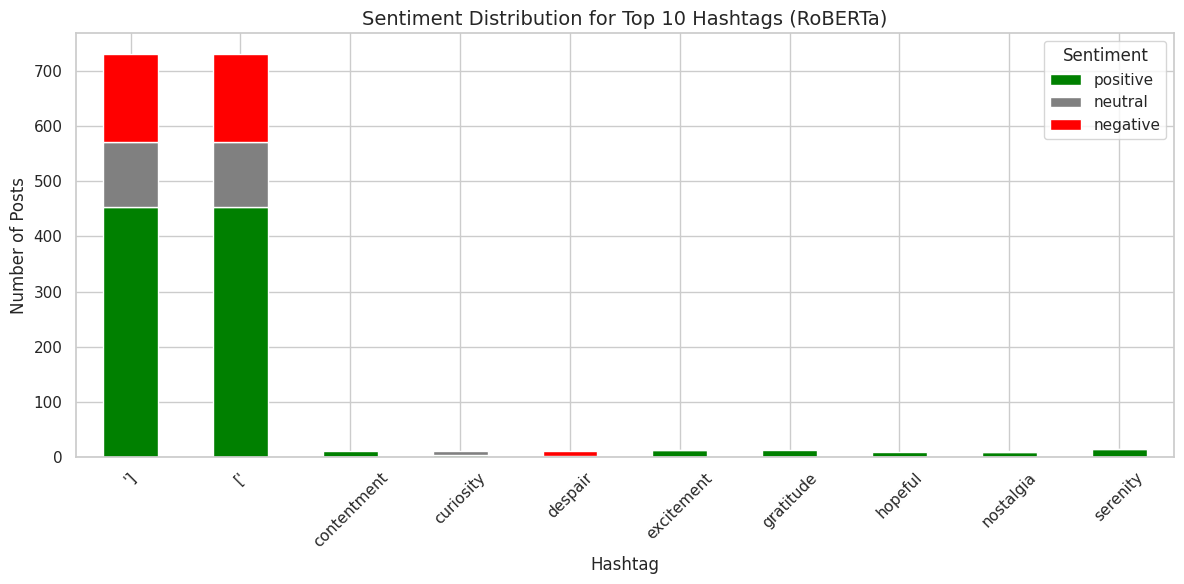

In [ ]:
# Assuming your main DataFrame is called 'data'
# and it has columns: 'Hashtags' and 'predicted_sentiment'

# Drop missing
df = data[['Hashtags', 'predicted_sentiment']].dropna()

# Expand hashtags
expanded = []
for _, row in df.iterrows():
    tags = str(row['Hashtags']).replace('#', ' ').split()
    for tag in tags:
        clean_tag = tag.strip().lower()
        if clean_tag:
            expanded.append((clean_tag, row['predicted_sentiment']))

# Convert to DataFrame
hashtags_df = pd.DataFrame(expanded, columns=['Hashtag', 'Sentiment'])

top10 = hashtags_df['Hashtag'].value_counts().nlargest(10).index
top10_df = hashtags_df[hashtags_df['Hashtag'].isin(top10)]

# Group and pivot
sentiment_counts = top10_df.groupby(['Hashtag', 'Sentiment']).size().unstack(fill_value=0)
sentiment_counts = sentiment_counts[['positive', 'neutral', 'negative']]  # order columns


# Plot
sentiment_counts.plot(kind='bar', stacked=True, figsize=(12, 6),
                      color=['green', 'gray', 'red'])

plt.title('Sentiment Distribution for Top 10 Hashtags (RoBERTa)', fontsize=14)
plt.xlabel('Hashtag')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter

# Drop missing hashtag entries
hashtag_series = data['Hashtags'].dropna()

# Flatten all hashtags into one list
all_hashtags = []

for tags in hashtag_series:
    tags = str(tags).replace('#', ' ')
    all_hashtags.extend([tag.strip().lower() for tag in tags.split() if tag.strip() != ''])

# Count frequency
hashtag_counts = Counter(all_hashtags)
top_10_hashtags = hashtag_counts.most_common(10)

# Display
for tag, count in top_10_hashtags:
    print(f"{tag}: {count} posts")

[': 732 posts
']: 732 posts
serenity: 15 posts
gratitude: 13 posts
excitement: 13 posts
despair: 11 posts
nostalgia: 11 posts
contentment: 10 posts
curiosity: 10 posts
awe: 9 posts


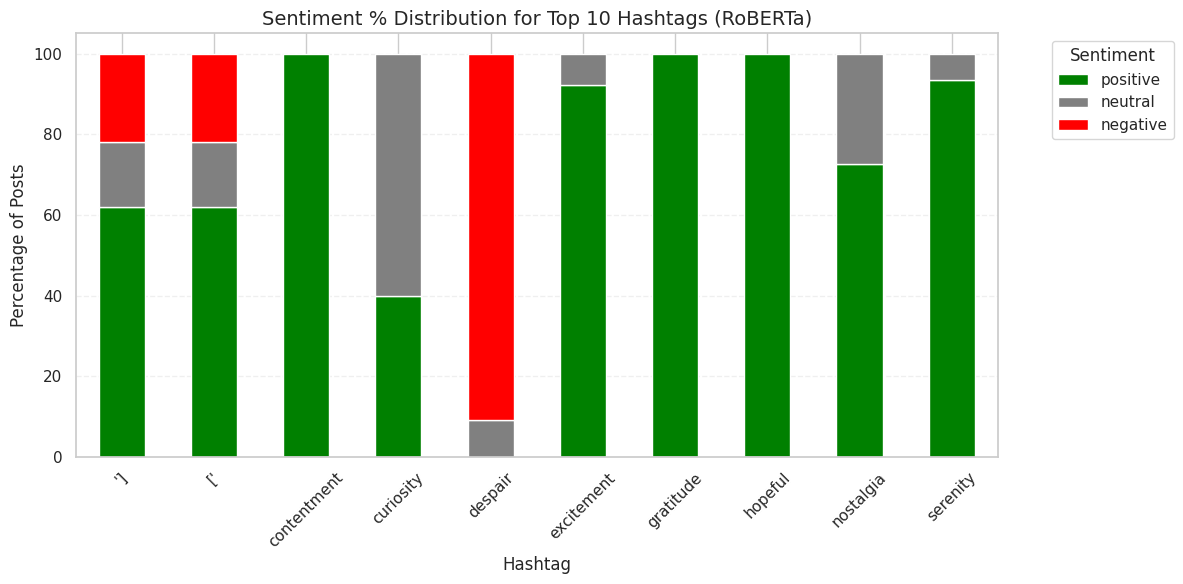

In [ ]:
# Group and pivot
sentiment_counts = top10_df.groupby(['Hashtag', 'Sentiment']).size().unstack(fill_value=0)

# Ensure all sentiment columns are present
for sentiment in ['positive', 'neutral', 'negative']:
    if sentiment not in sentiment_counts.columns:
        sentiment_counts[sentiment] = 0

# Reorder and normalize to 100%
sentiment_counts = sentiment_counts[['positive', 'neutral', 'negative']]
sentiment_percent = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0) * 100

# Plot
sentiment_percent.plot(kind='bar', stacked=True, figsize=(12, 6),
                       color=['green', 'gray', 'red'])

plt.title('Sentiment % Distribution for Top 10 Hashtags (RoBERTa)', fontsize=14)
plt.xlabel('Hashtag')
plt.ylabel('Percentage of Posts')
plt.xticks(rotation=45)
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Platform-Specific Analysis:

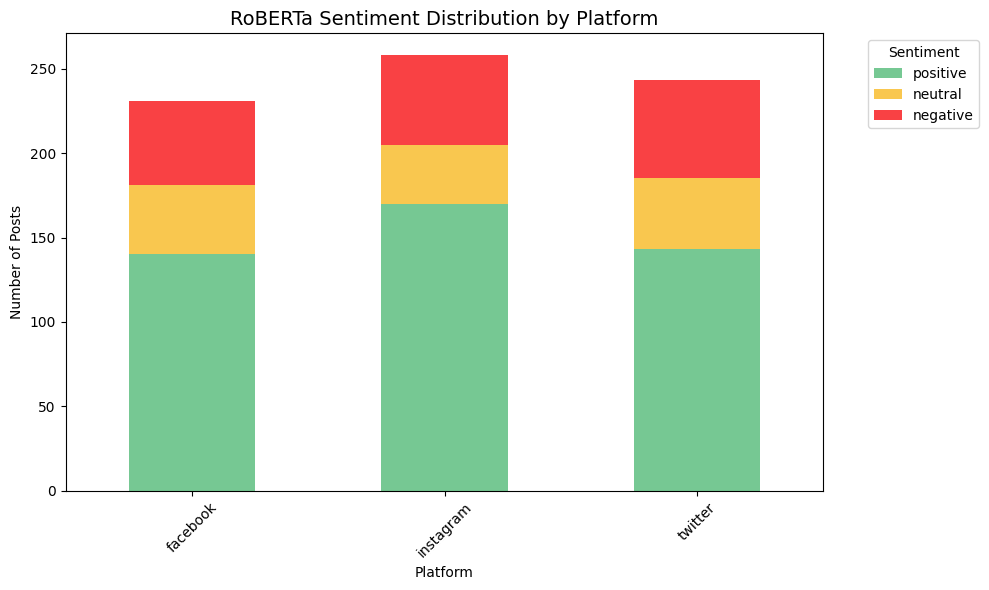

In [ ]:
# Clean platform names
data['Platform'] = data['Platform'].str.strip().str.lower()

# Count of sentiments per platform
platform_sentiment = data.groupby(['Platform', 'predicted_sentiment']).size().unstack(fill_value=0)

# Reorder columns for consistent color mapping
platform_sentiment = platform_sentiment[['positive', 'neutral', 'negative']]

# Define custom colors
colors = ['#76c893', '#f9c74f', '#f94144']

# Plot
ax = platform_sentiment.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)

plt.title('RoBERTa Sentiment Distribution by Platform', fontsize=14)
plt.xlabel('Platform')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)

# Optional: move legend to the right
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

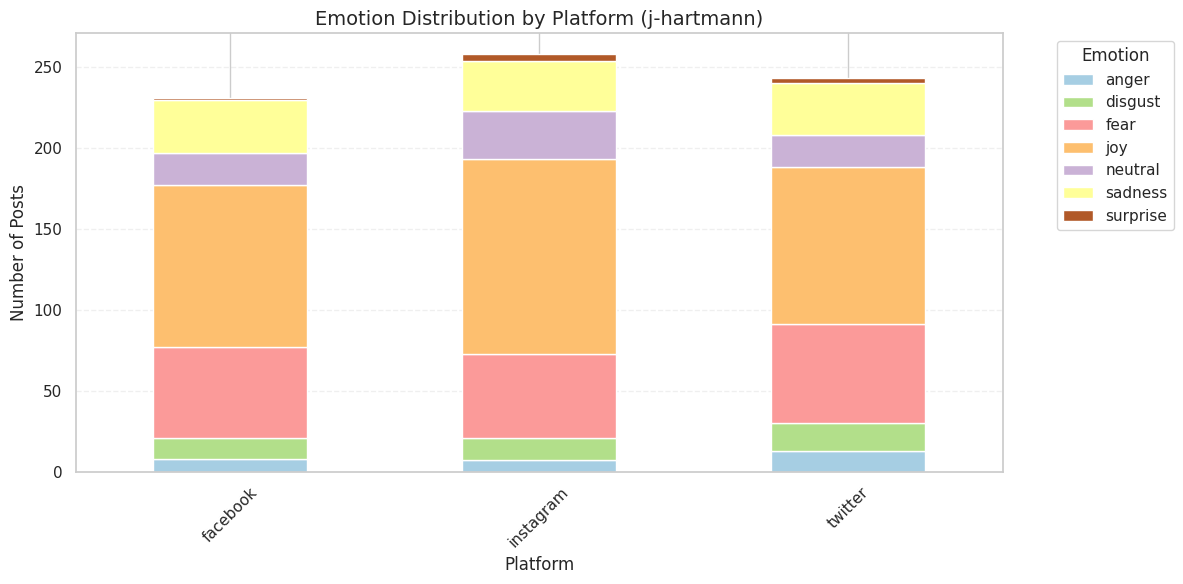

In [ ]:
# Ensure 'Platform' and 'predicted_emotion' columns are clean
data['Platform'] = data['Platform'].str.strip().str.lower()
data['predicted_emotion'] = data['predicted_emotion'].str.strip().str.lower()

# Group and count emotions per platform
platform_emotion = data.groupby(['Platform', 'predicted_emotion']).size().unstack(fill_value=0)

# Plot
platform_emotion.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Paired')

plt.title('Emotion Distribution by Platform (j-hartmann)', fontsize=14)
plt.xlabel('Platform')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.legend(title='Emotion')
# Move legend to left side
plt.legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


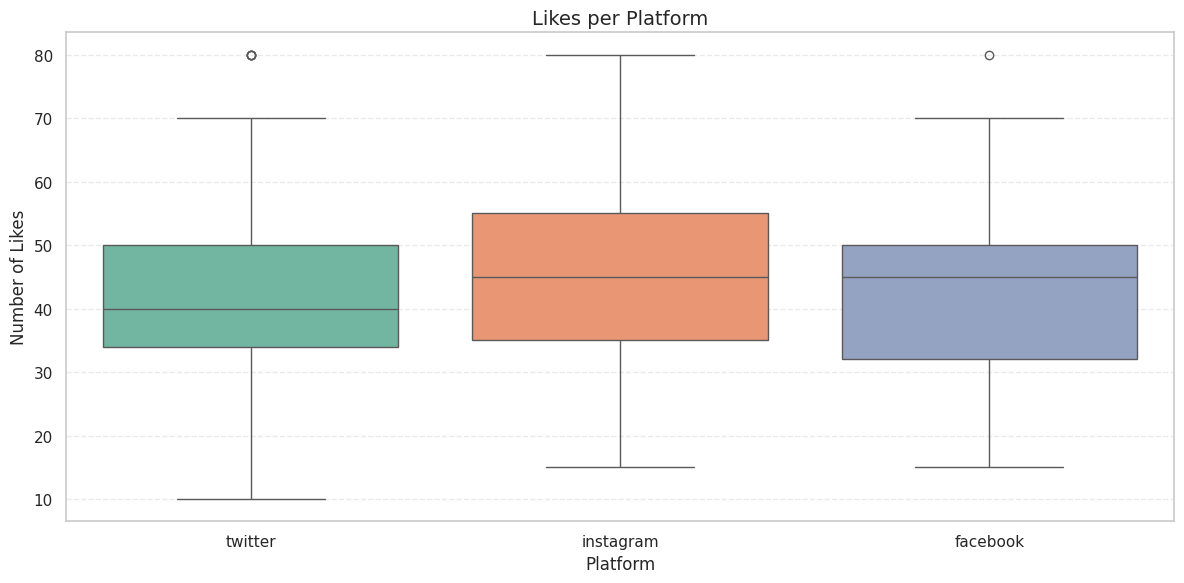

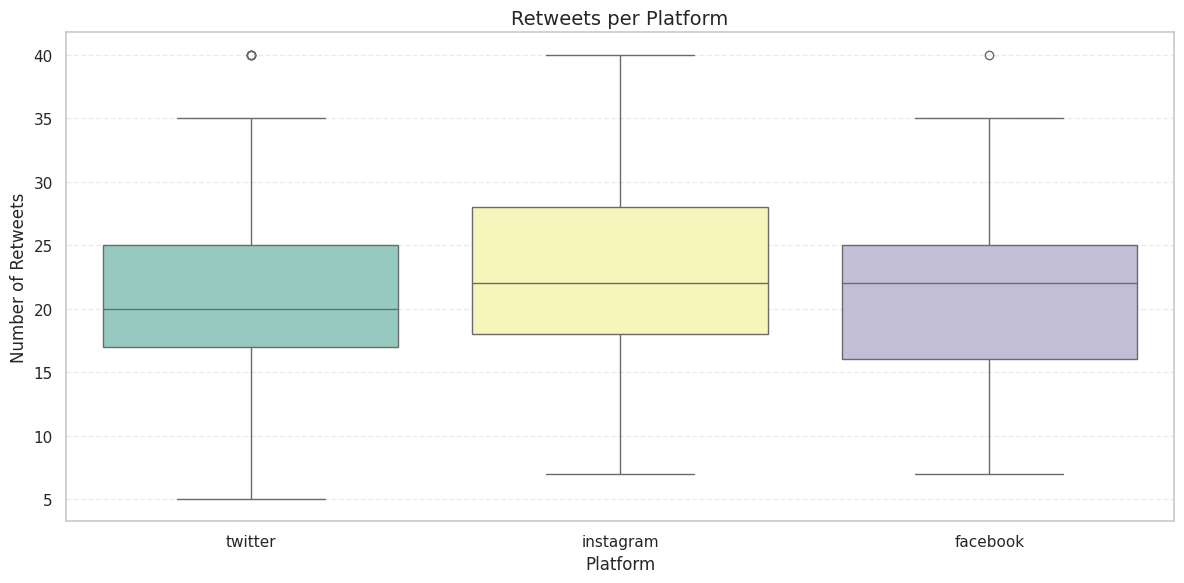

In [ ]:
# Box plot: Likes/retweets per platform

# Clean platform column (just in case)
data['Platform'] = data['Platform'].str.strip().str.lower()

# Set style
sns.set(style='whitegrid')

# Plot: Likes per platform
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x='Platform', y='Likes', palette='Set2')
plt.title('Likes per Platform', fontsize=14)
plt.ylabel('Number of Likes')
plt.xlabel('Platform')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Plot: Retweets per platform
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x='Platform', y='Retweets', palette='Set3')
plt.title('Retweets per Platform', fontsize=14)
plt.ylabel('Number of Retweets')
plt.xlabel('Platform')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

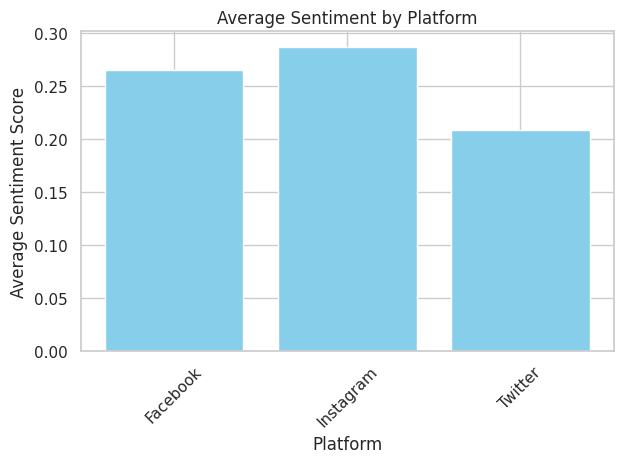

In [ ]:
# Convert all platform names to lowercase and remove extra spaces
data['Platform'] = data['Platform'].str.strip()

# Now, group and plot again
avg_sentiment = data.groupby('Platform')['Sentiment'].mean()

# Plot the corrected data
plt.bar(avg_sentiment.index, avg_sentiment.values, color='skyblue')
plt.xlabel("Platform")
plt.ylabel("Average Sentiment Score")
plt.title("Average Sentiment by Platform")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Geographical Trends:

In [ ]:
!pip install -U kaleido

# Map RoBERTa sentiment to numeric score
sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}
data['sentiment_score'] = data['predicted_sentiment'].map(sentiment_map)

# Clean and lowercase country names
data['Country'] = data['Country'].str.strip().str.lower()

# Group by country and calculate average sentiment
country_sentiment = data.groupby('Country')['sentiment_score'].mean().reset_index()

import plotly.express as px

# Capitalize country names for better matching
country_sentiment['Country'] = country_sentiment['Country'].str.title()

# Create map
fig = px.choropleth(
    country_sentiment,
    locations='Country',
    locationmode='country names',
    color='sentiment_score',
    color_continuous_scale=['red', 'lightgray', 'green'],
    range_color=(-1, 1),
    title='Average Sentiment by Country (RoBERTa)'
)

fig.update_geos(showframe=False, showcoastlines=True)
fig.show()

# Save the figure as a static image (requires kaleido)
fig.write_image("average_sentiment_by_country.png", width=1200, height=700)

In [ ]:
# Make sure country and emotion columns are clean
data['Country'] = data['Country'].str.strip().str.lower()
data['predicted_emotion'] = data['predicted_emotion'].str.strip().str.lower()

# Filter for non-null countries and emotions
emotion_df = data[['Country', 'predicted_emotion']].dropna()

# Total posts per country
total_per_country = emotion_df.groupby('Country').size()

# Joy posts per country
joy_counts = emotion_df[emotion_df['predicted_emotion'] == 'joy'].groupby('Country').size()

# Create percentage DataFrame
joy_percent = (joy_counts / total_per_country * 100).fillna(0).reset_index()
joy_percent.columns = ['Country', 'Joy_Percentage']

# Capitalize for map matching
joy_percent['Country'] = joy_percent['Country'].str.title()

import plotly.express as px

fig = px.choropleth(
    joy_percent,
    locations='Country',
    locationmode='country names',
    color='Joy_Percentage',
    color_continuous_scale='YlGn',
    title='Percentage of Posts Expressing Joy by Country'
)

fig.update_geos(showframe=False, showcoastlines=True)
fig.show()

### Temporal Patterns

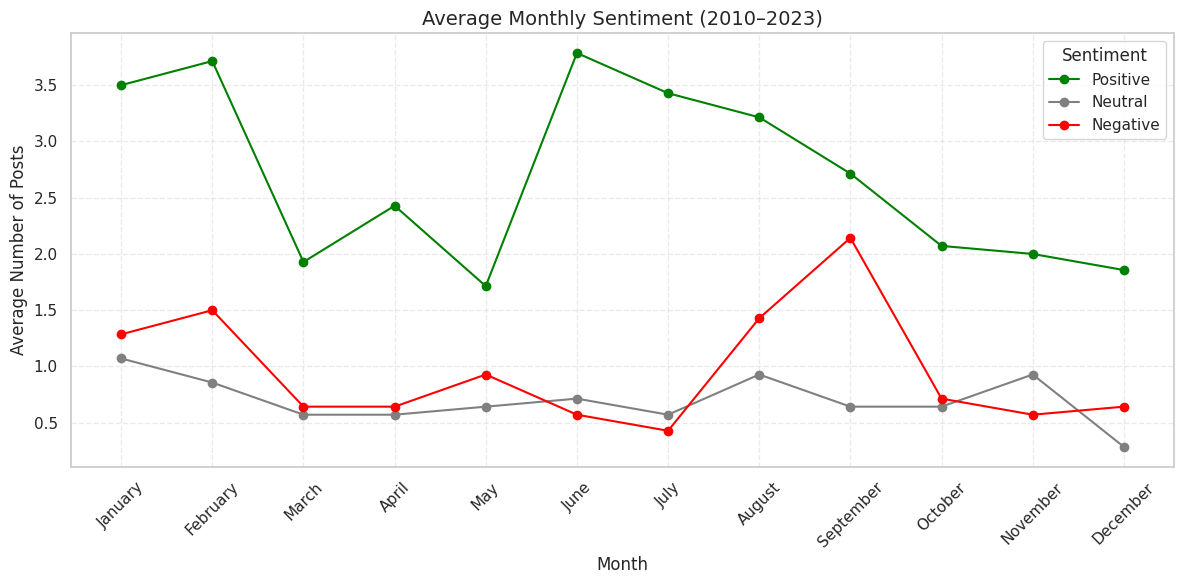

In [ ]:
import calendar

# Convert 'Timestamp' column to datetime if not already
data['Timestamp'] = pd.to_datetime(data['Timestamp'])

# Filter between 2010 and 2023
data_filtered = data[(data['Timestamp'].dt.year >= 2010) & (data['Timestamp'].dt.year <= 2023)]

# Extract calendar month name and year
data_filtered['Month'] = data_filtered['Timestamp'].dt.month_name()
data_filtered['Month_Num'] = data_filtered['Timestamp'].dt.month  # for sorting

# Count number of posts per month & sentiment
monthly_counts = data_filtered.groupby(['Month_Num', 'Month', 'predicted_sentiment']).size().reset_index(name='Count')

# Average over 14 years
monthly_avg = monthly_counts.copy()
monthly_avg['Avg_Count'] = monthly_avg['Count'] / 14

# Pivot so each sentiment is a column
pivot_df = monthly_avg.pivot(index='Month_Num', columns='predicted_sentiment', values='Avg_Count').fillna(0)

# Add month names for x-axis
pivot_df['Month'] = [calendar.month_name[i] for i in pivot_df.index]

# Reorder columns
pivot_df = pivot_df[['Month', 'positive', 'neutral', 'negative']]

plt.figure(figsize=(12, 6))

# Plot each sentiment line
plt.plot(pivot_df['Month'], pivot_df['positive'], marker='o', label='Positive', color='green')
plt.plot(pivot_df['Month'], pivot_df['neutral'], marker='o', label='Neutral', color='gray')
plt.plot(pivot_df['Month'], pivot_df['negative'], marker='o', label='Negative', color='red')

plt.title('Average Monthly Sentiment (2010–2023)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Average Number of Posts')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()


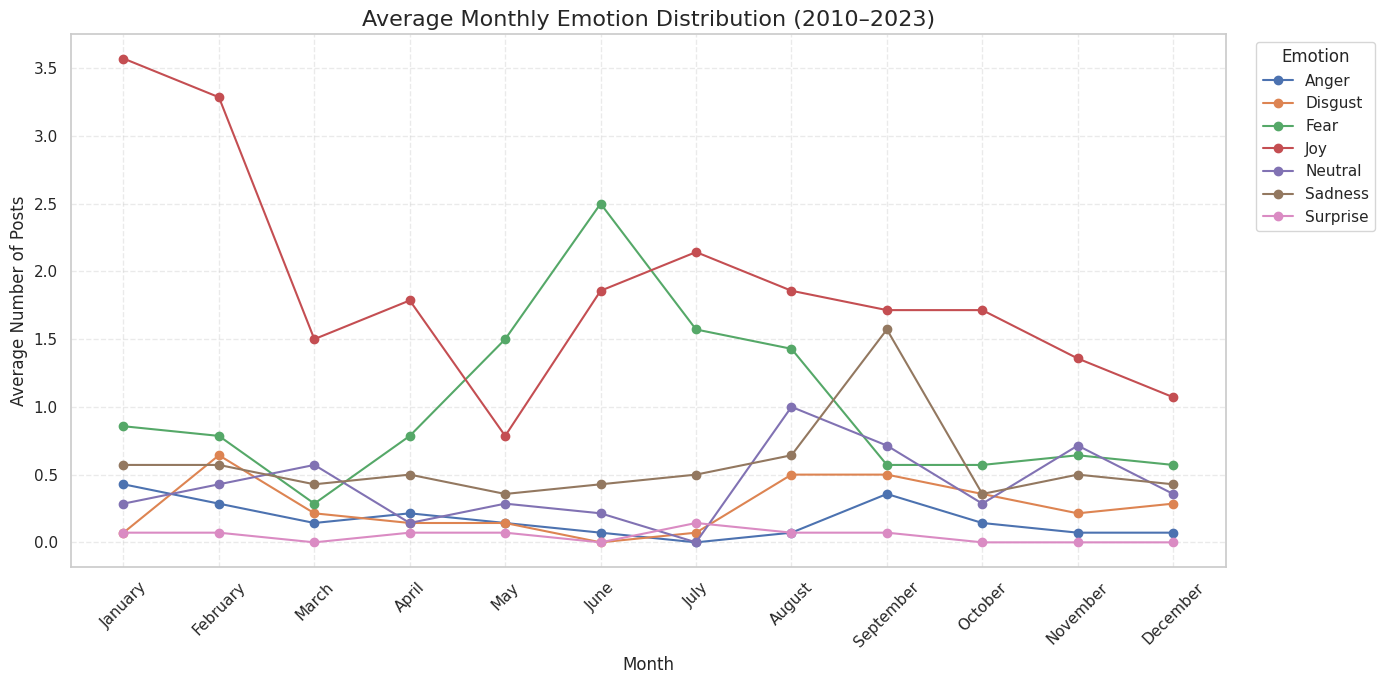

In [ ]:
import calendar

# Ensure 'Timestamp' is datetime
data['Timestamp'] = pd.to_datetime(data['Timestamp'])

# Filter by years
emotion_data = data[(data['Timestamp'].dt.year >= 2010) & (data['Timestamp'].dt.year <= 2023)]

# Extract month name and number
emotion_data['Month'] = emotion_data['Timestamp'].dt.month_name()
emotion_data['Month_Num'] = emotion_data['Timestamp'].dt.month


# Group by emotion and calendar month
emotion_monthly_counts = (
    emotion_data.groupby(['Month_Num', 'Month', 'predicted_emotion'])
    .size()
    .reset_index(name='Count')
)

# Average per year (2010–2023 = 14 years)
emotion_monthly_counts['Avg_Count'] = emotion_monthly_counts['Count'] / 14


# Pivot to wide format: each emotion gets a column
pivot_emotion = emotion_monthly_counts.pivot(
    index='Month_Num', columns='predicted_emotion', values='Avg_Count'
).fillna(0)

# Add month names for x-axis
pivot_emotion['Month'] = [calendar.month_name[i] for i in pivot_emotion.index]

# Set up plot
plt.figure(figsize=(14, 7))

# Plot all available emotions
for emotion in pivot_emotion.columns.drop('Month'):
    plt.plot(pivot_emotion['Month'], pivot_emotion[emotion], marker='o', label=emotion.capitalize())

plt.title('Average Monthly Emotion Distribution (2010–2023)', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Average Number of Posts')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Emotion', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


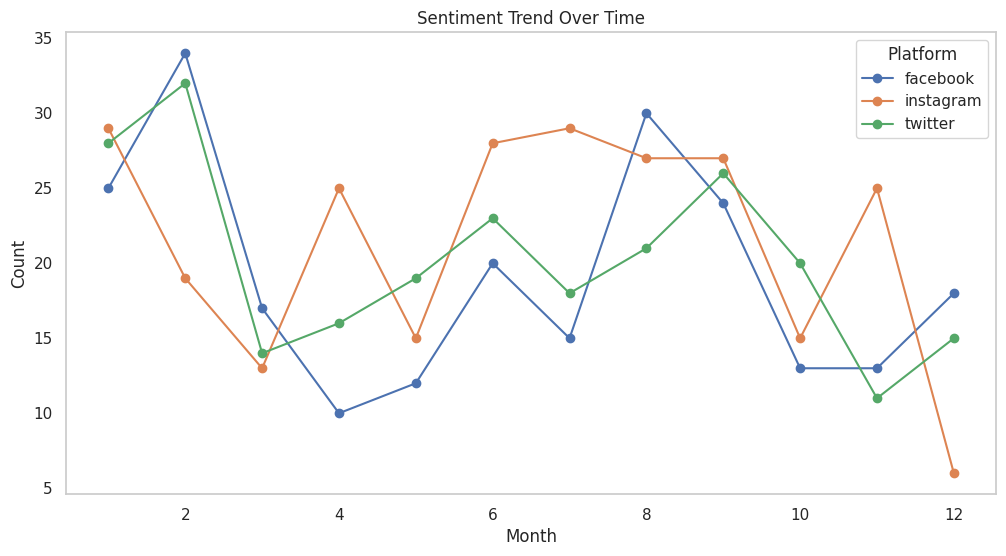

In [ ]:
# Group by Month and Platform, then count occurrences
sentiment_trend = data.groupby(['Month', 'Platform']).size().unstack().fillna(0)

# Plotting
sentiment_trend.plot(figsize=(12, 6), marker='o')
plt.title('Sentiment Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Count')
plt.legend(title='Platform')
plt.grid()
plt.show()

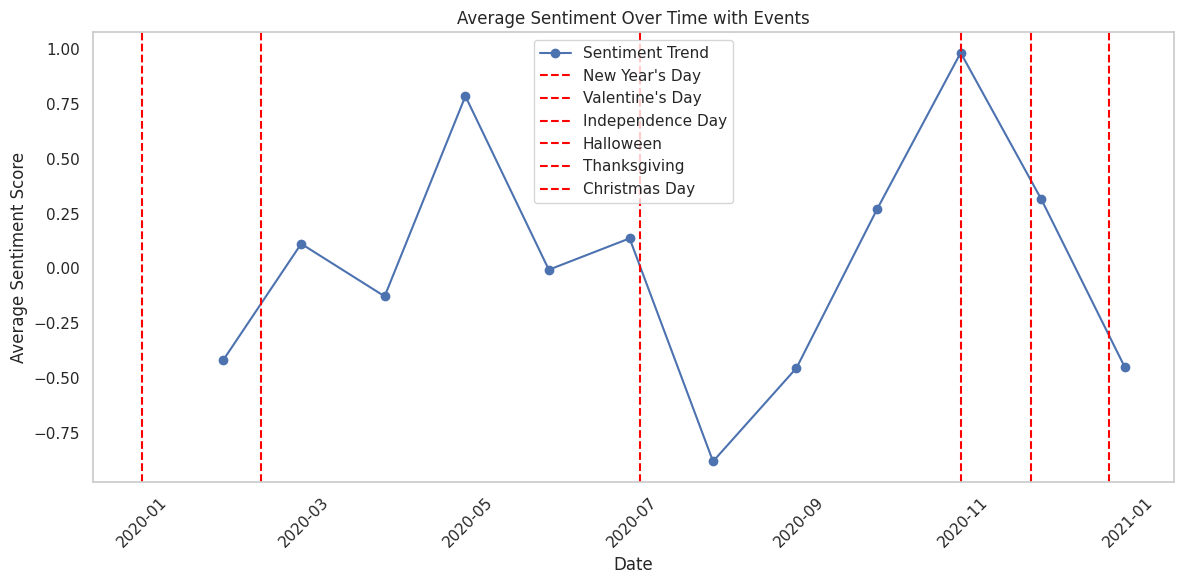

In [ ]:
# Generate example time-series sentiment data
dates = pd.date_range(start='2020-01-01', periods=12, freq='ME')  # Monthly dates
sentiment_scores = np.random.uniform(-1, 1, len(dates))  # Random sentiment scores between -1 and 1
monthly_sentiment = pd.Series(sentiment_scores, index=dates)

# Define key events
events = {
    "New Year's Day": "2020-01-01",
    "Valentine's Day": "2020-02-14",
    "Independence Day": "2020-07-04",
    "Halloween": "2020-10-31",
    "Thanksgiving": "2020-11-26",
    "Christmas Day": "2020-12-25"
}

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_sentiment.index, monthly_sentiment.values, marker='o', label='Sentiment Trend')

# Mark events with vertical lines
for event, date in events.items():
    plt.axvline(pd.to_datetime(date), color='red', linestyle='--', label=event)

# Customize the plot
plt.title('Average Sentiment Over Time with Events')
plt.xlabel('Date')
plt.ylabel('Average Sentiment Score')
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()

# Display the plot
plt.show()

<ipython-input-26-33d18e487e0e>:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sentiment = data.resample('M', on='Timestamp')['Sentiment'].mean()


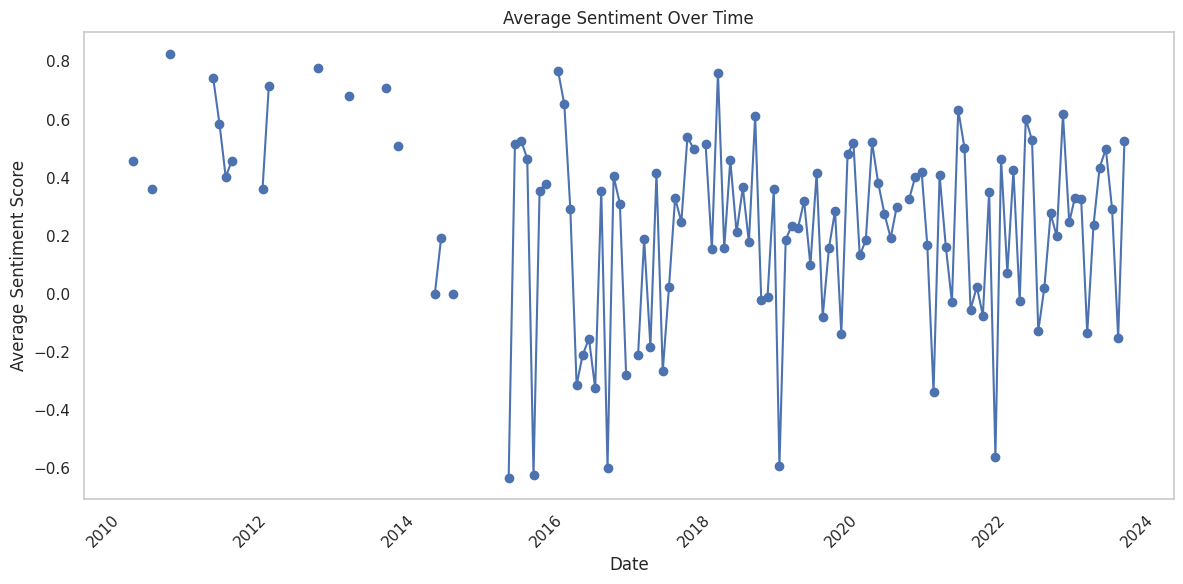

In [ ]:
# Convert 'Timestamp' to datetime
data['Timestamp'] = pd.to_datetime(data['Timestamp'])

# Group by month and calculate average sentiment
monthly_sentiment = data.resample('M', on='Timestamp')['Sentiment'].mean()

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(monthly_sentiment.index, monthly_sentiment.values, marker='o')
plt.title('Average Sentiment Over Time')
plt.xlabel('Date')
plt.ylabel('Average Sentiment Score')
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

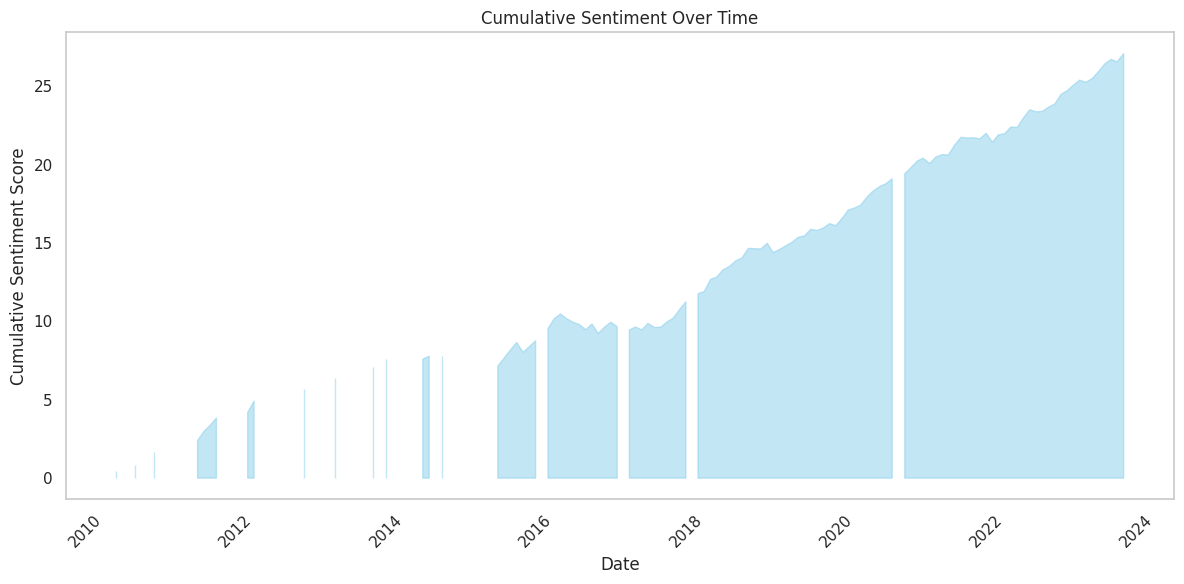

In [ ]:
# Area chart of cumulative sentiment over time
cumulative_sentiment = monthly_sentiment.cumsum()

plt.figure(figsize=(12, 6))
plt.fill_between(cumulative_sentiment.index, cumulative_sentiment.values, color='skyblue', alpha=0.5)
plt.title('Cumulative Sentiment Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Sentiment Score')
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Others

<ipython-input-10-61abbb8d2f94>:26: UserWarning: Mismatched number of handles and labels: len(handles) = 0 len(labels) = 3
  plt.legend(handles=handles[1:], labels=['Positive', 'Neutral', 'Negative'], title='Sentiment', title_fontsize=12, fontsize=10)
<ipython-input-10-61abbb8d2f94>:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(handles=handles[1:], labels=['Positive', 'Neutral', 'Negative'], title='Sentiment', title_fontsize=12, fontsize=10)


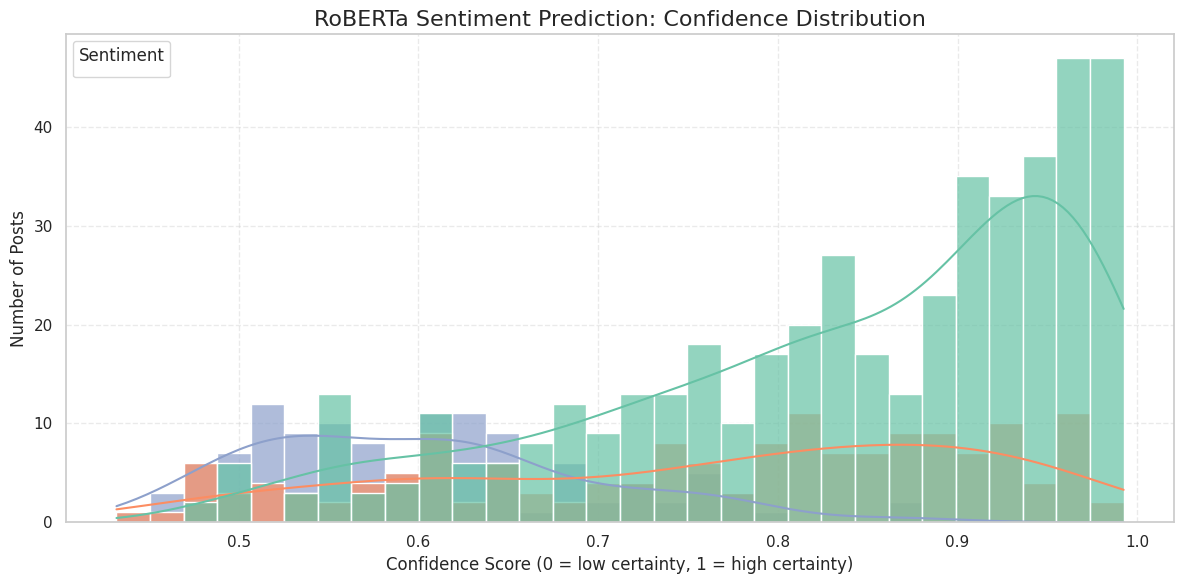

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style
sns.set(style='whitegrid')

# Create the plot
plt.figure(figsize=(12, 6), dpi=100)
hist = sns.histplot(
    data=data,
    x='confidence',
    hue='predicted_sentiment',
    bins=30,
    kde=True,
    palette='Set2',
    alpha=0.7
)

# Add a clear title and labels
plt.title('RoBERTa Sentiment Prediction: Confidence Distribution', fontsize=16)
plt.xlabel('Confidence Score (0 = low certainty, 1 = high certainty)', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)

# Manually define legend labels to match hue colors
handles, labels = hist.get_legend_handles_labels()
plt.legend(handles=handles[1:], labels=['Positive', 'Neutral', 'Negative'], title='Sentiment', title_fontsize=12, fontsize=10)

# Tidy layout
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

/usr/local/lib/python3.11/dist-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


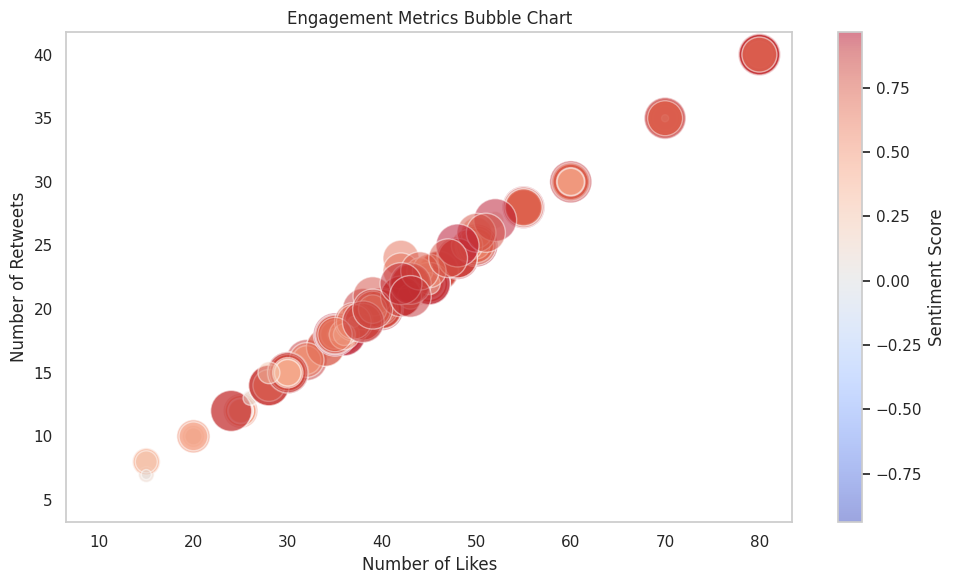

In [ ]:
# Bubble chart of Likes vs. Retweets colored by Sentiment
plt.figure(figsize=(10, 6))
plt.scatter(data['Likes'], data['Retweets'], s=data['Sentiment']*1000, alpha=0.5, c=data['Sentiment'], cmap='coolwarm', edgecolors='w')
plt.title('Engagement Metrics Bubble Chart')
plt.xlabel('Number of Likes')
plt.ylabel('Number of Retweets')
plt.colorbar(label='Sentiment Score')
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
   print(data['Sentiment'].dtype)  # Check the data type
   print(data['Sentiment'].unique())  # Check unique values

float64
[ 0.8221 -0.4767  0.6239  0.4003  0.      0.5423 -0.0772 -0.296   0.128
  0.3382  0.7574  0.4767 -0.1531  0.743   0.1531  0.6114  0.3818  0.4404
  0.3612  0.4753  0.5267  0.5719  0.34    0.5093  0.5859  0.765   0.4215
  0.4585 -0.3182 -0.7845 -0.5267  0.9098  0.872   0.8977  0.7177  0.8625
  0.4926  0.4588  0.8172  0.5106  0.8122  0.6597  0.0772  0.4019  0.5411
  0.802  -0.7783 -0.872  -0.4939  0.7506 -0.5709  0.7777  0.6908  0.8784
  0.68    0.807   0.7184 -0.3818  0.8883 -0.4215 -0.25    0.7906  0.7269
  0.4939 -0.6407  0.6486  0.7579  0.7783  0.6886  0.8271  0.7717  0.5994
  0.3182  0.6249  0.6705  0.6808  0.7003  0.8807  0.5574  0.8442  0.7096
  0.6369 -0.6597 -0.4404 -0.8225 -0.6124 -0.5574 -0.2732 -0.91   -0.6249
 -0.7096  0.25   -0.7717  0.0516 -0.128  -0.6908 -0.7003 -0.5994 -0.836
 -0.3612 -0.1027 -0.7269 -0.4019 -0.1779 -0.0516 -0.4588  0.296  -0.2023
  0.2263 -0.34    0.8591  0.891   0.6124  0.8779  0.1027 -0.0258  0.8885
  0.8658  0.8225  0.8555  0.9169  0.9325  0.9

In [ ]:
import os
print(os.listdir('/content/'))

['.config', 'sample_data']


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", 101)

In [ ]:
data = pd.read_csv("/content/archive.zip")

FileNotFoundError: [Errno 2] No such file or directory: '/content/archive.zip'

In [ ]:
data.shape

(732, 23)

In [ ]:

# Print first few rows of data
data.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['Unnamed: 0.1'].plot(kind='hist', bins=20, title='Unnamed: 0.1')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['Unnamed: 0'].plot(kind='hist', bins=20, title='Unnamed: 0')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['Retweets'].plot(kind='hist', bins=20, title='Retweets')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['Platform'].value_counts()
    for x_label, grp in _df_23.groupby('User')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('User')
_ = plt.ylabel('Platform')

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_24['Text'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_24, x='index', y='Text', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_25['Sentiment'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_25, x='index', y='Sentiment', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_26['Timestamp'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_26, x='index', y='Timestamp', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_27['User'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_27, x='index', y='User', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

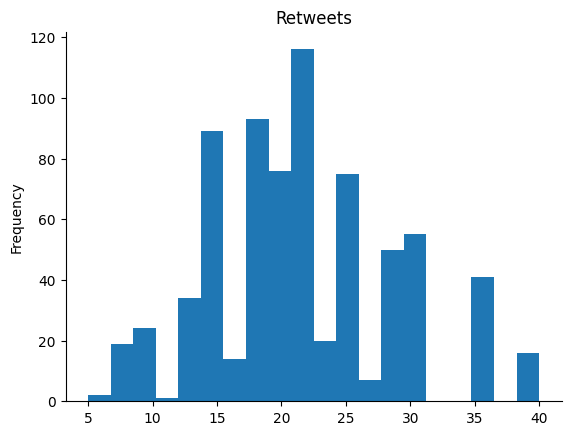

In [ ]:
# @title Retweets

from matplotlib import pyplot as plt
data['Retweets'].plot(kind='hist', bins=20, title='Retweets')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
#Handling null values in categorical columns
data = data.dropna()

In [ ]:

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB


In [ ]:
# create another copy of dataset and append encoded features to it
data_train = data.copy()
data_train.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19
